# Saliency Maps for Neural Networks
### A hands-on guide — from pixels to explanations

---

**What you will build and understand:**

1. A convolutional neural network (CNN) that classifies handwritten digits
2. **Vanilla Gradient** saliency — the simplest pixel-attribution method
3. **Grad-CAM** — the most widely used spatial attribution method
4. A side-by-side comparison of both methods
5. The limitations every practitioner must know

**Prerequisites:** basic Python, introductory neural networks (forward pass, backprop).
**Time:** ~2 hours to read + run (including ~3 min training).

> **Run Notebook 00 first** to download MNIST and create `mnist_subset.npz`.


## 1. Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")   # CPU is fine for MNIST

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")


PyTorch 2.4.0+cpu  |  device: cpu


## 2. Load the dataset

We load the `mnist_subset.npz` saved by Notebook 00 and apply standard MNIST normalisation.

**Why normalise?**
Neural networks converge faster when inputs have zero mean and unit variance.
The values `mean=0.1307, std=0.3081` are the global pixel statistics of MNIST.


In [2]:
# ── Load subset ──────────────────────────────
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "mnist_subset.npz")
data = np.load(DATA_PATH)

X_train_raw = data["X_train"]   # (6000, 1, 28, 28) float32, range [0, 1]
y_train_raw = data["y_train"]
X_test_raw  = data["X_test"]    # (1000, 1, 28, 28)
y_test_raw  = data["y_test"]

print(f"Training set : {X_train_raw.shape}  labels: {y_train_raw.shape}")
print(f"Test set     : {X_test_raw.shape}   labels: {y_test_raw.shape}")


Training set : (6000, 1, 28, 28)  labels: (6000,)
Test set     : (1000, 1, 28, 28)   labels: (1000,)


In [3]:
# ── Normalise & convert to tensors ───────────
MEAN, STD = 0.1307, 0.3081

def normalise(X):
    return (X - MEAN) / STD

X_train = torch.tensor(normalise(X_train_raw), dtype=torch.float32)
y_train = torch.tensor(y_train_raw,             dtype=torch.long)
X_test  = torch.tensor(normalise(X_test_raw),  dtype=torch.float32)
y_test  = torch.tensor(y_test_raw,              dtype=torch.long)

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print(f"Pixel range after normalisation: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Batches per epoch: {len(train_loader)}")


Pixel range after normalisation: [-0.42, 2.82]
Batches per epoch: 47


---
## 3. CNN Architecture

We build a simple two-block convolutional network.
Understanding the architecture is important because **Grad-CAM hooks into specific layers**.

```
Input: (1, 28, 28)
    │
    ▼
Conv Block 1: Conv2d(1→32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    Output: (32, 13, 13)
    │
    ▼
Conv Block 2: Conv2d(32→64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    Output: (64, 6, 6)       ← Grad-CAM hooks here
    │
    ▼
Flatten: 64 × 6 × 6 = 2,304
    │
    ▼
FC1: 2304 → 256 → ReLU → Dropout(0.4)
    │
    ▼
FC2: 256 → 10  (logits for 10 digit classes)
```

**Why two conv layers?** The first layer learns low-level features (edges, strokes).
The second learns higher-level patterns (curves, corners). Grad-CAM visualises
what the *second* layer found relevant for the prediction.


In [4]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Convolutional blocks ──────────────────
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 28×28 → 14×14
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 14×14 → 7×7
        )

        # ── Fully-connected head ──────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return self.classifier(x)


model = DigitCNN().to(DEVICE)

# ── Parameter count ───────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print()
print(model)


Total parameters    : 824,650
Trainable parameters: 824,650

DigitCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


---
## 4. Training

We train for **5 epochs** with the Adam optimiser and cross-entropy loss.
On CPU this takes roughly **3–5 minutes**.

The model weights are saved to `cnn_mnist.pt` so you can reload without retraining.


In [5]:
WEIGHTS_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "cnn_mnist.pt")

def train_model(model, loader, n_epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": []}
    model.train()

    for epoch in range(1, n_epochs + 1):
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct       += predicted.eq(labels).sum().item()
            total         += labels.size(0)

        scheduler.step()
        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        print(f"Epoch {epoch}/{n_epochs}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

    return history


# ── Train or load ─────────────────────────────
if os.path.exists(WEIGHTS_PATH):
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
    print(f"Loaded pre-trained weights from {WEIGHTS_PATH}")
    history = None
else:
    print("Training from scratch...")
    history = train_model(model, train_loader, n_epochs=5)
    torch.save(model.state_dict(), WEIGHTS_PATH)
    print(f"Weights saved to {WEIGHTS_PATH}")


Training from scratch...
Epoch 1/5  loss=0.7047  acc=0.7767
Epoch 2/5  loss=0.1781  acc=0.9467
Epoch 3/5  loss=0.1064  acc=0.9683
Epoch 4/5  loss=0.0689  acc=0.9800
Epoch 5/5  loss=0.0606  acc=0.9822
Weights saved to /app/notebooks/cnn_mnist.pt


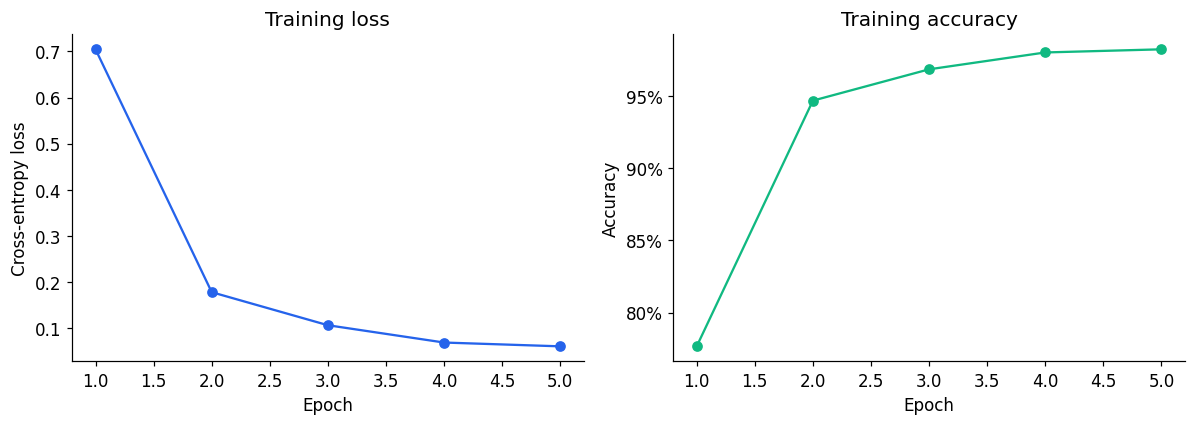

In [6]:
# ── Training curves (if we just trained) ─────
if history:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], "o-", color="#2563EB")
    axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy loss")

    axes[1].plot(epochs, history["train_acc"], "o-", color="#10B981")
    axes[1].set(title="Training accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("(Skipped — loaded pre-trained weights)")


---
## 5. Evaluation

Before trusting any saliency map, we need to confirm the model is actually working well.
**Saliency maps from a poorly-trained model are meaningless.**


In [7]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    return acc, np.array(all_preds), np.array(all_labels)


train_acc, _, _ = evaluate(model, train_loader)
test_acc, test_preds, test_labels = evaluate(model, test_loader)

print(f"Train accuracy : {train_acc:.4f}  ({train_acc:.1%})")
print(f"Test  accuracy : {test_acc:.4f}  ({test_acc:.1%})")


Train accuracy : 0.9918  (99.2%)
Test  accuracy : 0.9820  (98.2%)


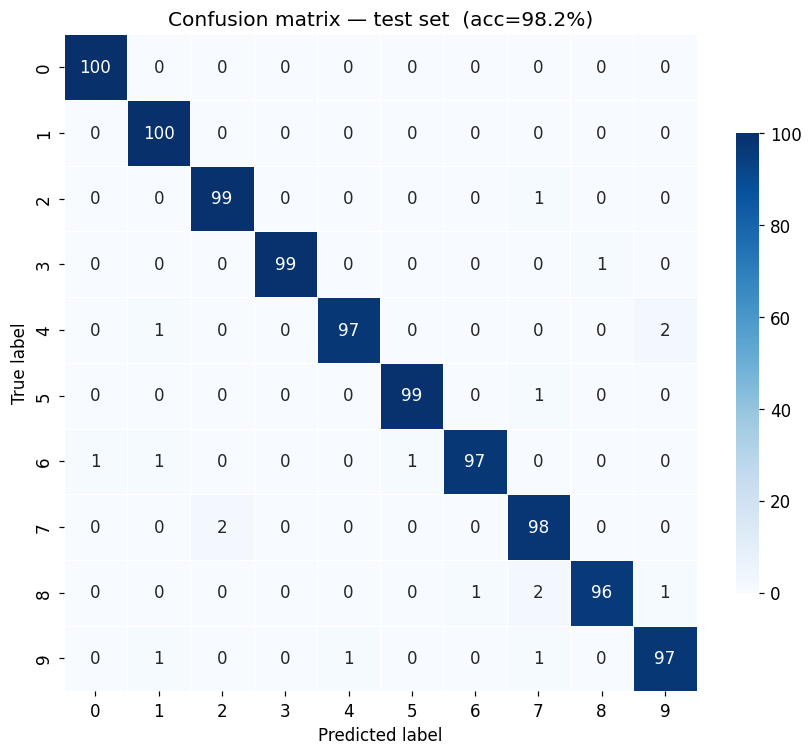

Off-diagonal cells = misclassifications.


In [24]:
# ── Confusion matrix ─────────────────────────
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.4, cbar_kws={"shrink": 0.7})
ax.set(title=f"Confusion matrix — test set  (acc={test_acc:.1%})",
       xlabel="Predicted label", ylabel="True label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()
print("Off-diagonal cells = misclassifications.")


---
## 6. Theory — What is a saliency map?

### 6.1 The core question

A trained CNN maps an image $x \in \mathbb{R}^{1 \times 28 \times 28}$ to class scores
$S(x) \in \mathbb{R}^{10}$.

> **Question:** Which pixels contributed most to the network predicting class $c$?

A **saliency map** $M \in \mathbb{R}^{28 \times 28}$ assigns an importance score to each pixel.
High values = "the model cares about this pixel for this prediction."

### 6.2 Two families of methods

| Family | Idea | Examples |
|---|---|---|
| **Gradient-based** | Compute $\partial S_c / \partial x$ — how sensitive is the score to each pixel? | Vanilla Gradient, Integrated Gradients, SmoothGrad |
| **Activation-based** | Inspect intermediate feature maps and how they relate to the final score | Grad-CAM, CAM, Score-CAM |

We implement one from each family.

### 6.3 Why do we need these?

A CNN's `forward` pass is a black box: millions of multiplications produce a number.
Saliency maps give us a **post-hoc explanation** — they do not change the model, they
just help us understand what it already learned.

---
## 7. Vanilla Gradient Saliency

### 7.1 Algorithm

For image $x$ and predicted class $c$:

$$M^{\text{grad}}_{ij} = \left| \frac{\partial S_c(x)}{\partial x_{ij}} \right|$$

1. Set `requires_grad=True` on the input image.
2. Forward pass → get class score $S_c$.
3. Backward pass → compute $\partial S_c / \partial x$.
4. Take the absolute value (we care about *magnitude* of influence, not direction).

**Intuition:** If slightly changing pixel $(i,j)$ would greatly increase $S_c$, that pixel is important.
This is exactly the definition of a partial derivative.

### 7.2 What the gradient tells us

$\frac{\partial S_c}{\partial x_{ij}} > 0$ → increasing this pixel raises the score for class $c$.

$\frac{\partial S_c}{\partial x_{ij}} < 0$ → increasing this pixel lowers the score for class $c$.

Taking $|\cdot|$ combines both into "how sensitive is $S_c$ to this pixel?"


In [25]:
def vanilla_gradient(model, image, target_class):
    """
    Compute vanilla gradient saliency map.

    Args:
        model        : trained nn.Module
        image        : tensor of shape (1, H, W) — single image, NOT batched
        target_class : int — the class to explain (usually the predicted class)

    Returns:
        saliency : numpy array of shape (H, W), values >= 0
    """
    model.eval()

    # Add batch dimension and enable gradient tracking on the input
    x = image.unsqueeze(0).to(DEVICE)   # (1, 1, H, W)
    x.requires_grad_(True)

    # Forward pass
    output = model(x)                   # (1, 10)
    score  = output[0, target_class]    # scalar — the score for our target class

    # Backward pass — only for the target class score
    model.zero_grad()
    score.backward()

    # Gradient w.r.t. input: shape (1, 1, H, W) → squeeze to (H, W)
    saliency = x.grad.data.abs().squeeze().cpu().numpy()

    return saliency


# ── Quick test ────────────────────────────────
sample_img, sample_label = test_ds[0]
pred_class = model(sample_img.unsqueeze(0)).argmax(dim=1).item()
sal = vanilla_gradient(model, sample_img, pred_class)

print(f"Input shape  : {sample_img.shape}")
print(f"Saliency shape: {sal.shape}")
print(f"True label   : {sample_label.item()}  |  Predicted: {pred_class}")
print(f"Saliency range: [{sal.min():.4f}, {sal.max():.4f}]")


Input shape  : torch.Size([1, 28, 28])
Saliency shape: (28, 28)
True label   : 0  |  Predicted: 0
Saliency range: [0.0000, 0.2148]


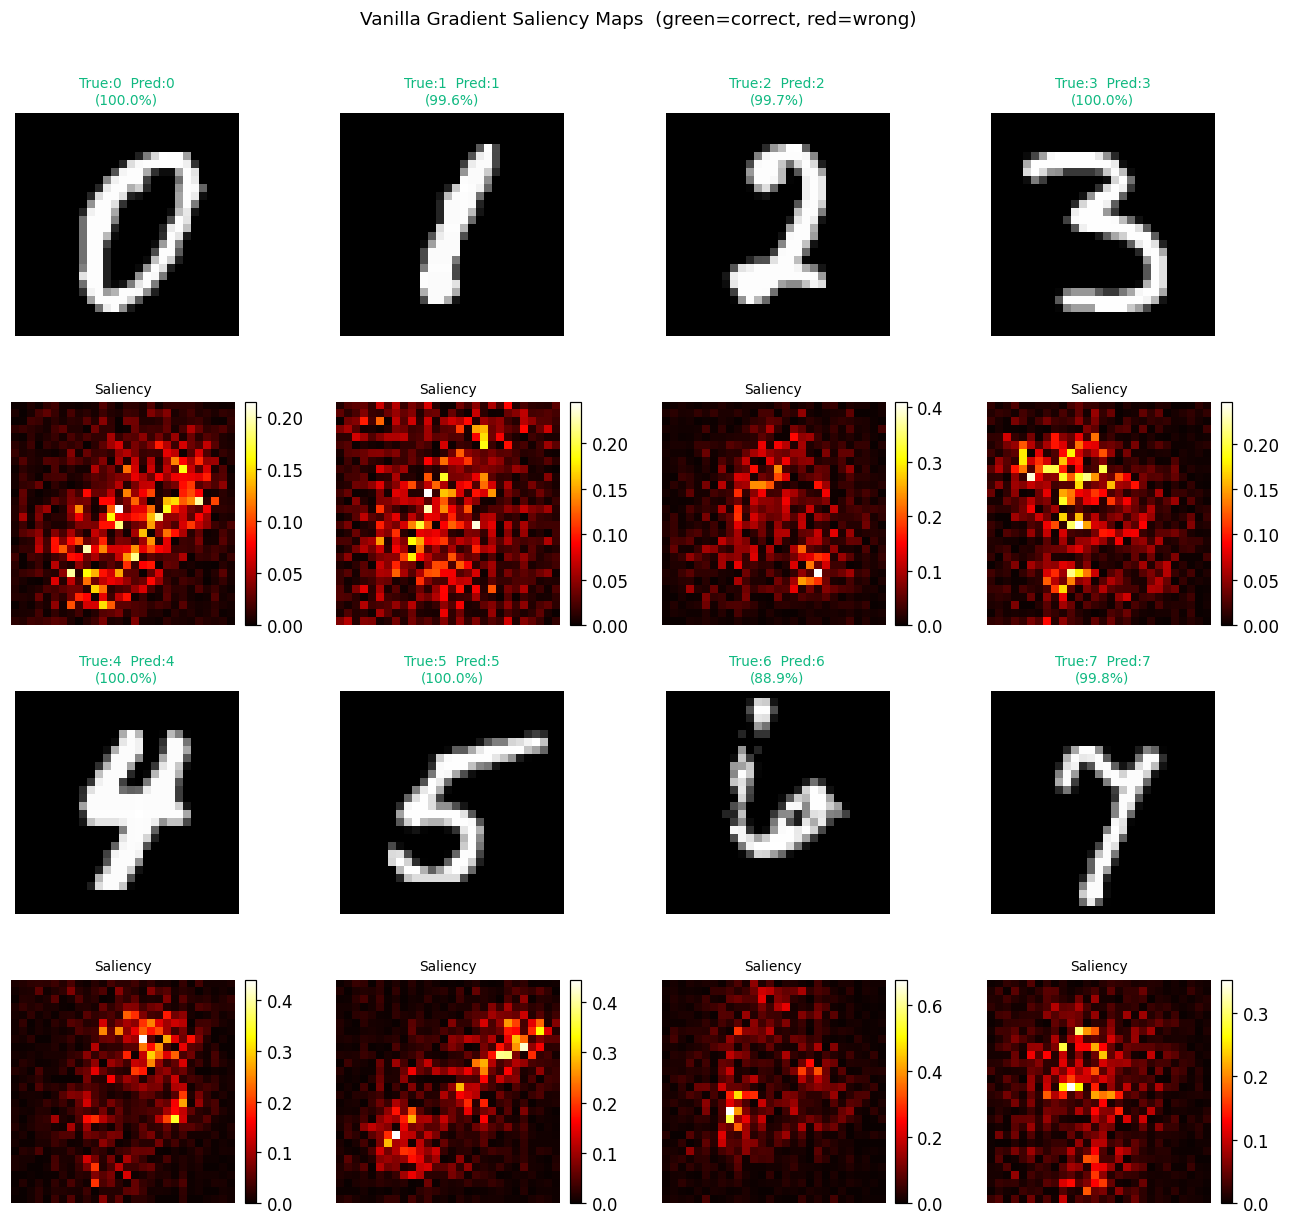

In [10]:
# ── Visualise for multiple samples ───────────
def show_vanilla_gradient(model, dataset, indices, cols=4, save_path=None):
    """Display original image + saliency map side by side for multiple samples."""
    n = len(indices)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 3, rows * 5.5))

    for plot_idx, ds_idx in enumerate(indices):
        row_img = (plot_idx // cols) * 2
        col     = plot_idx % cols

        image, true_label = dataset[ds_idx]
        with torch.no_grad():
            logits = model(image.unsqueeze(0))
            prob   = F.softmax(logits, dim=1)
        pred_class  = logits.argmax(dim=1).item()
        confidence  = prob[0, pred_class].item()

        saliency = vanilla_gradient(model, image, pred_class)

        # Row 1: original image (denormalised)
        ax_img = axes[row_img][col]
        img_show = image.squeeze().numpy() * STD + MEAN
        ax_img.imshow(img_show, cmap="gray", vmin=0, vmax=1)
        title_color = "#10B981" if pred_class == true_label else "#EF4444"
        ax_img.set_title(f"True:{true_label}  Pred:{pred_class}\n({confidence:.1%})",
                         color=title_color, fontsize=9)
        ax_img.axis("off")

        # Row 2: saliency map
        ax_sal = axes[row_img + 1][col]
        im = ax_sal.imshow(saliency, cmap="hot", vmin=0)
        ax_sal.set_title("Saliency", fontsize=9)
        ax_sal.axis("off")
        plt.colorbar(im, ax=ax_sal, fraction=0.046, pad=0.04)

    # Hide unused subplots
    for i in range(n, rows * cols):
        axes[(i // cols) * 2][i % cols].axis("off")
        axes[(i // cols) * 2 + 1][i % cols].axis("off")

    fig.suptitle("Vanilla Gradient Saliency Maps  (green=correct, red=wrong)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()


# Pick 2 correct examples per digit (first 10 total from test set)
np.random.seed(42)
sample_indices = []
for digit in range(10):
    idxs = np.where(test_labels == digit)[0]
    correct_idxs = [i for i in idxs if test_preds[i] == digit]
    if correct_idxs:
        sample_indices.append(correct_idxs[0])

show_vanilla_gradient(model, test_ds, sample_indices[:8],
                      cols=4, save_path="vanilla_gradient.png")


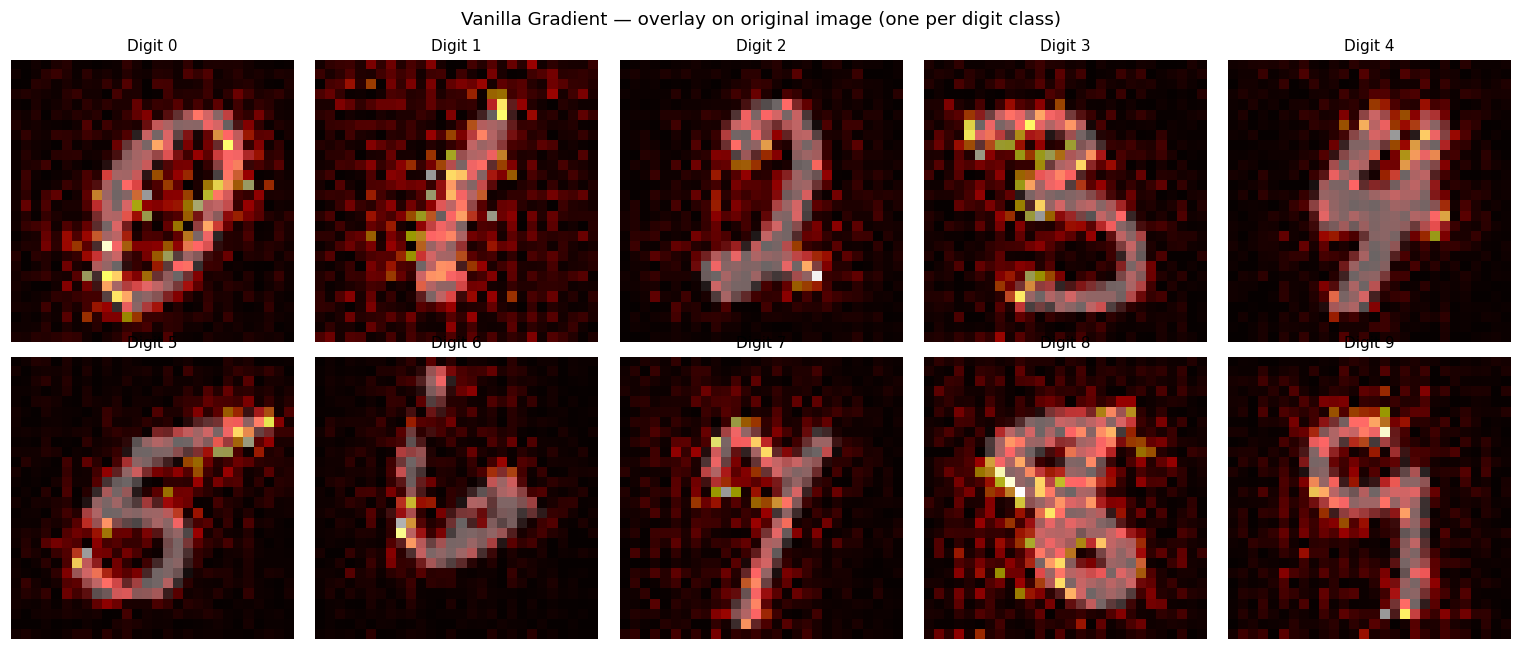

In [11]:
# ── Overlay: saliency on top of image ─────────
def overlay_saliency(image, saliency, alpha=0.6):
    """Blend saliency heatmap over the original image."""
    import matplotlib.cm as cm
    img_np  = (image.squeeze().numpy() * STD + MEAN)
    sal_norm = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    heatmap = cm.hot(sal_norm)[:, :, :3]   # RGB, drop alpha
    blended = alpha * heatmap + (1 - alpha) * np.stack([img_np]*3, axis=-1)
    return np.clip(blended, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Vanilla Gradient — overlay on original image (one per digit class)", fontsize=12)

for digit in range(10):
    ax   = axes[digit // 5][digit % 5]
    idxs = np.where(test_labels == digit)[0]
    ok   = [i for i in idxs if test_preds[i] == digit]
    if not ok:
        ax.axis("off"); continue

    img, _ = test_ds[ok[0]]
    pred   = test_preds[ok[0]]
    sal    = vanilla_gradient(model, img, pred)
    overlay = overlay_saliency(img, sal)

    ax.imshow(overlay)
    ax.set_title(f"Digit {digit}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("vanilla_overlay.png", dpi=110, bbox_inches="tight")
plt.show()


### 7.3 What do you see?

The bright pixels in the saliency maps highlight the **ink strokes** of each digit.

- For a **1**, the vertical stroke is highlighted.
- For a **0**, the oval outline lights up.
- For a **9**, the closed loop and descending tail.

This is *reassuring*: the model is looking at the right parts of the image.

But notice the saliency maps can be **noisy** — scattered bright pixels that seem
unrelated to the digit. This is a known weakness of vanilla gradient, which we
address with Grad-CAM.


---
## 8. Theory — Grad-CAM

*Gradient-weighted Class Activation Mapping* (Selvaraju et al., 2017) produces
**coarser but smoother** saliency maps by working at the level of feature maps
rather than individual pixels.

### 8.1 The algorithm

Let $A^k \in \mathbb{R}^{H' \times W'}$ be the $k$-th feature map of the
**last convolutional layer**, and $S_c$ the score for class $c$.

**Step 1 — Compute neuron importance weights:**
$$\alpha_k^c = \underbrace{\frac{1}{H'W'} \sum_{i,j}}_{\text{global avg pool}} \frac{\partial S_c}{\partial A^k_{ij}}$$

Each $\alpha_k^c$ is the "how useful is feature map $k$ for predicting class $c$?"

**Step 2 — Compute the weighted combination:**
$$\text{Grad-CAM}_c = \text{ReLU}\!\left( \sum_k \alpha_k^c \, A^k \right)$$

The ReLU discards features that *hurt* the prediction (negative contribution).

**Step 3 — Upsample** the resulting $(H', W')$ heatmap to the original image size.

### 8.2 Why the last conv layer?

Early layers capture generic edges/textures.
The **last** conv layer captures the most task-specific, semantically rich features.
Its spatial structure still corresponds to image regions, unlike the flat FC layers.

### 8.3 Hooks in PyTorch

We use `register_forward_hook` to capture the activations $A^k$ and
`register_full_backward_hook` to capture $\partial S_c / \partial A^k$
without modifying the model.


## 9. Grad-CAM — Implementation

In [12]:
class GradCAM:
    """
    Grad-CAM implementation using forward and backward hooks.

    Usage:
        gcam = GradCAM(model, target_layer=model.conv2[0])
        heatmap = gcam(image, target_class)
        gcam.remove_hooks()   # clean up when done
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.activations  = None   # will store forward activations A^k
        self.gradients    = None   # will store backward gradients dS_c/dA^k

        # Register hooks on the target layer
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        """Called automatically during the forward pass."""
        self.activations = output.detach()   # shape: (1, C, H', W')

    def _save_gradient(self, module, grad_input, grad_output):
        """Called automatically during the backward pass."""
        self.gradients = grad_output[0].detach()   # shape: (1, C, H', W')

    def __call__(self, image, target_class):
        """
        Compute Grad-CAM heatmap.

        Args:
            image        : tensor (1, H, W) — single image
            target_class : int

        Returns:
            heatmap : numpy array (H, W), values in [0, 1]
        """
        self.model.eval()
        x = image.unsqueeze(0).to(DEVICE)   # (1, 1, H, W)

        # Forward — triggers _save_activation
        output = self.model(x)              # (1, 10)
        score  = output[0, target_class]

        # Backward — triggers _save_gradient
        self.model.zero_grad()
        score.backward()

        # ── Compute alpha_k (global average pooled gradients) ────
        # gradients shape: (1, C, H', W')
        alpha = self.gradients.mean(dim=[2, 3], keepdim=True)   # (1, C, 1, 1)

        # ── Weighted sum of activations ──────────────────────────
        cam = (alpha * self.activations).sum(dim=1).squeeze()   # (H', W')
        cam = F.relu(cam)                                         # keep only positive

        # ── Normalise to [0, 1] ──────────────────────────────────
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        # ── Upsample to original image size (28x28) ─────────────
        cam = cam.unsqueeze(0).unsqueeze(0)           # (1, 1, H', W')
        cam = F.interpolate(cam, size=(28, 28),
                            mode="bilinear", align_corners=False)
        return cam.squeeze().cpu().numpy()            # (28, 28)

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# ── Instantiate on the LAST conv layer ────────
# model.conv2 is a nn.Sequential; [0] is the Conv2d layer itself
gcam = GradCAM(model, target_layer=model.conv2[0])

# Quick test
test_img, test_lbl = test_ds[0]
pred = model(test_img.unsqueeze(0)).argmax(dim=1).item()
heatmap = gcam(test_img, pred)
print(f"Grad-CAM output shape : {heatmap.shape}")
print(f"Heatmap range         : [{heatmap.min():.4f}, {heatmap.max():.4f}]")
print(f"True: {test_lbl}  Pred: {pred}")


Grad-CAM output shape : (28, 28)
Heatmap range         : [0.0000, 0.8618]
True: 0  Pred: 0


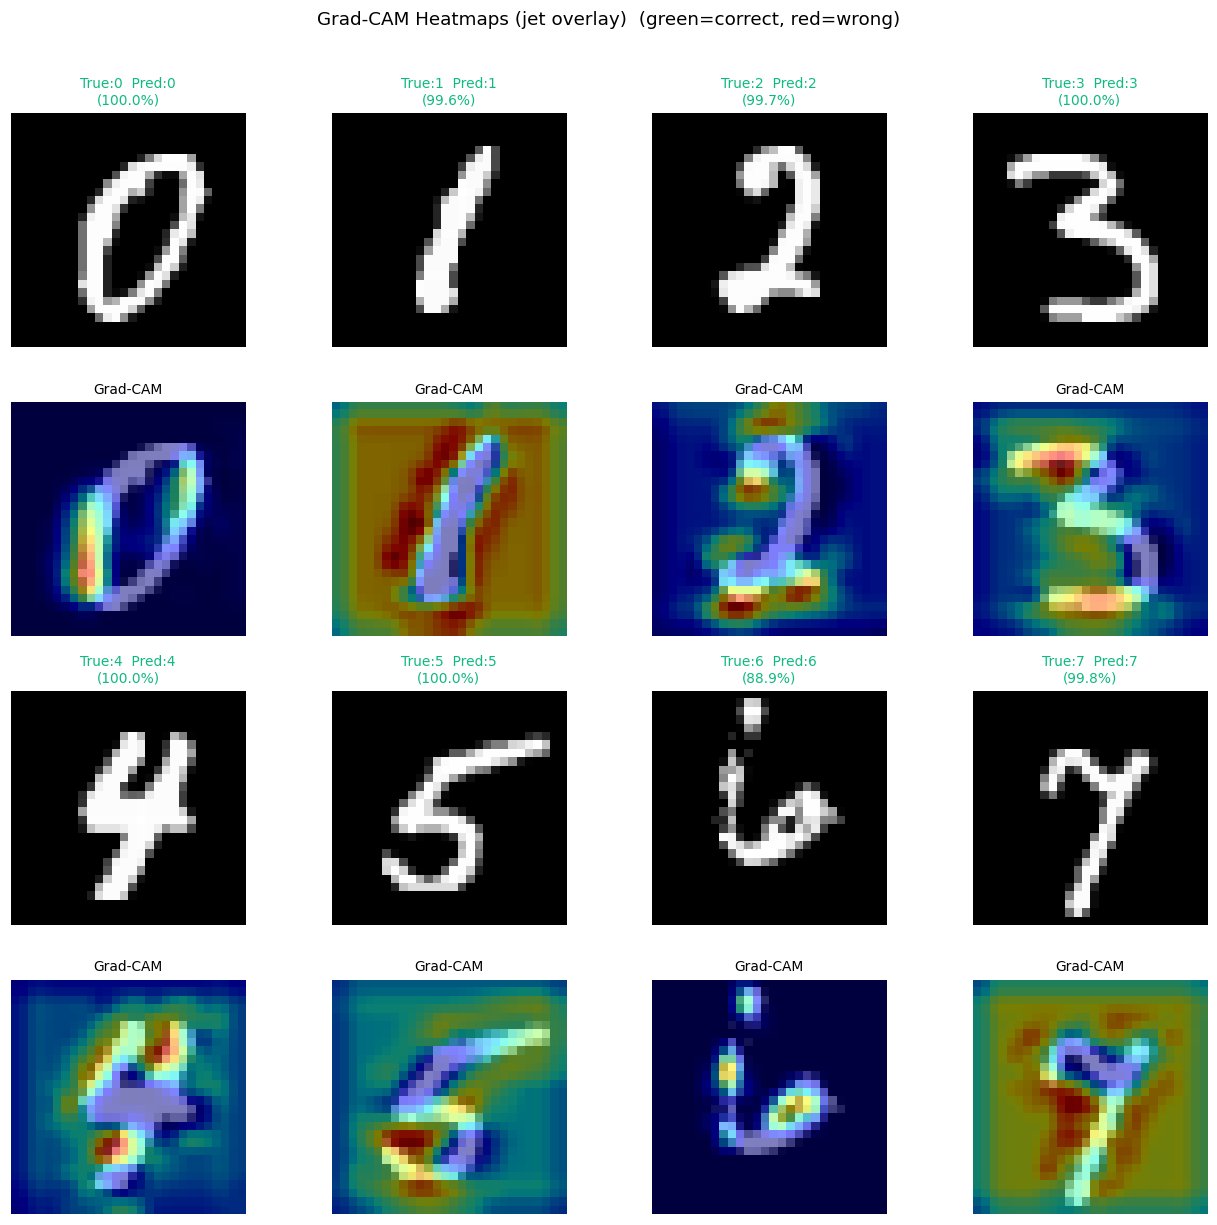

In [13]:
# ── Visualise: original + Grad-CAM overlay ────
def show_gradcam(gcam_fn, model, dataset, indices, cols=4, save_path=None):
    n    = len(indices)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 3, rows * 5.5))

    import matplotlib.cm as cm

    for plot_idx, ds_idx in enumerate(indices):
        row_img = (plot_idx // cols) * 2
        col_idx = plot_idx % cols

        image, true_label = dataset[ds_idx]
        with torch.no_grad():
            logits = model(image.unsqueeze(0))
            prob   = F.softmax(logits, dim=1)
        pred_class = logits.argmax(dim=1).item()
        confidence = prob[0, pred_class].item()

        heatmap = gcam_fn(image, pred_class)

        # Row 1: original image
        ax_img = axes[row_img][col_idx]
        img_show = image.squeeze().numpy() * STD + MEAN
        ax_img.imshow(img_show, cmap="gray", vmin=0, vmax=1)
        color = "#10B981" if pred_class == true_label else "#EF4444"
        ax_img.set_title(f"True:{true_label}  Pred:{pred_class}\n({confidence:.1%})",
                         color=color, fontsize=9)
        ax_img.axis("off")

        # Row 2: Grad-CAM heatmap blended with original
        ax_cam = axes[row_img + 1][col_idx]
        heatmap_rgb = cm.jet(heatmap)[:, :, :3]
        img_rgb     = np.stack([img_show] * 3, axis=-1)
        overlay     = 0.5 * heatmap_rgb + 0.5 * img_rgb
        ax_cam.imshow(np.clip(overlay, 0, 1))
        ax_cam.set_title("Grad-CAM", fontsize=9)
        ax_cam.axis("off")

    for i in range(n, rows * cols):
        axes[(i // cols) * 2][i % cols].axis("off")
        axes[(i // cols) * 2 + 1][i % cols].axis("off")

    fig.suptitle("Grad-CAM Heatmaps (jet overlay)  (green=correct, red=wrong)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()


show_gradcam(gcam, model, test_ds, sample_indices[:8],
             cols=4, save_path="gradcam.png")


---
## 10. Side-by-Side Comparison

Now we place Vanilla Gradient and Grad-CAM next to each other
for the same image and the same predicted class.

This reveals their complementary strengths and weaknesses.


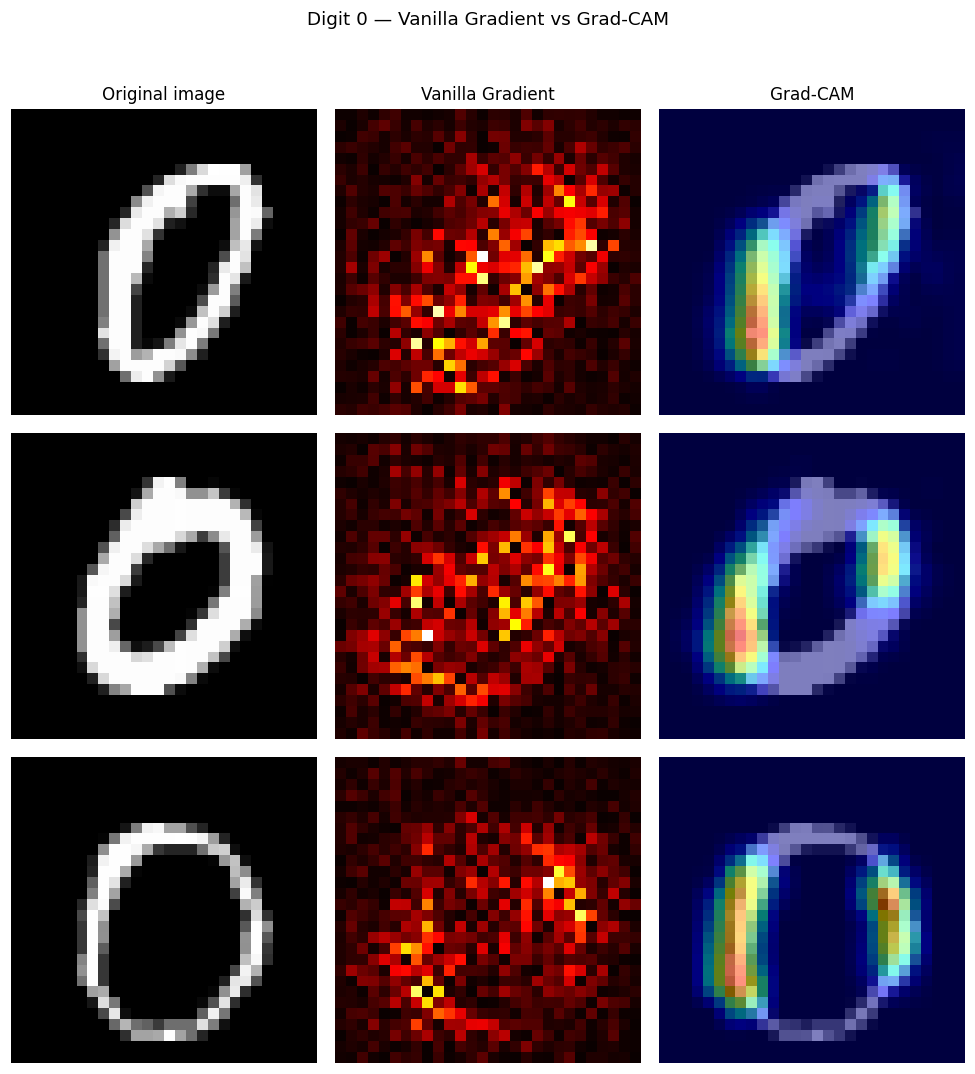

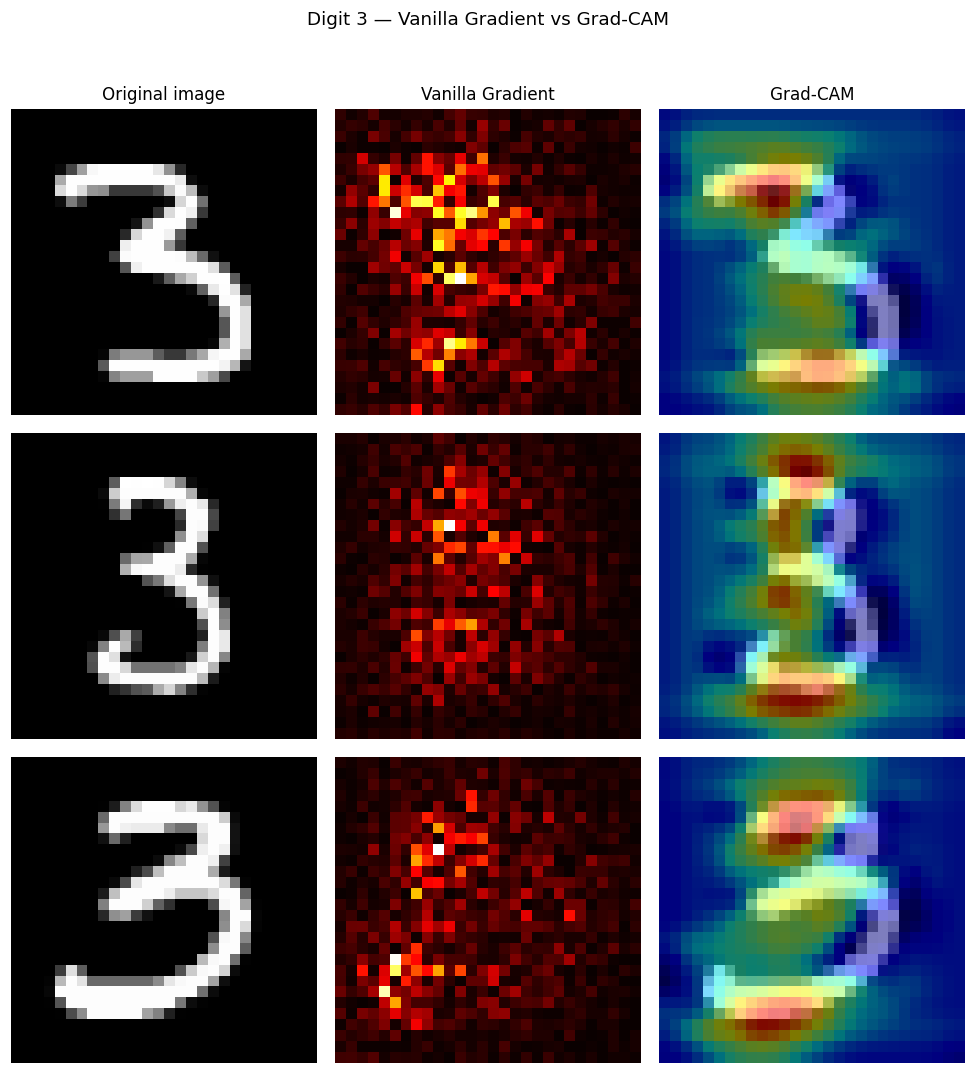

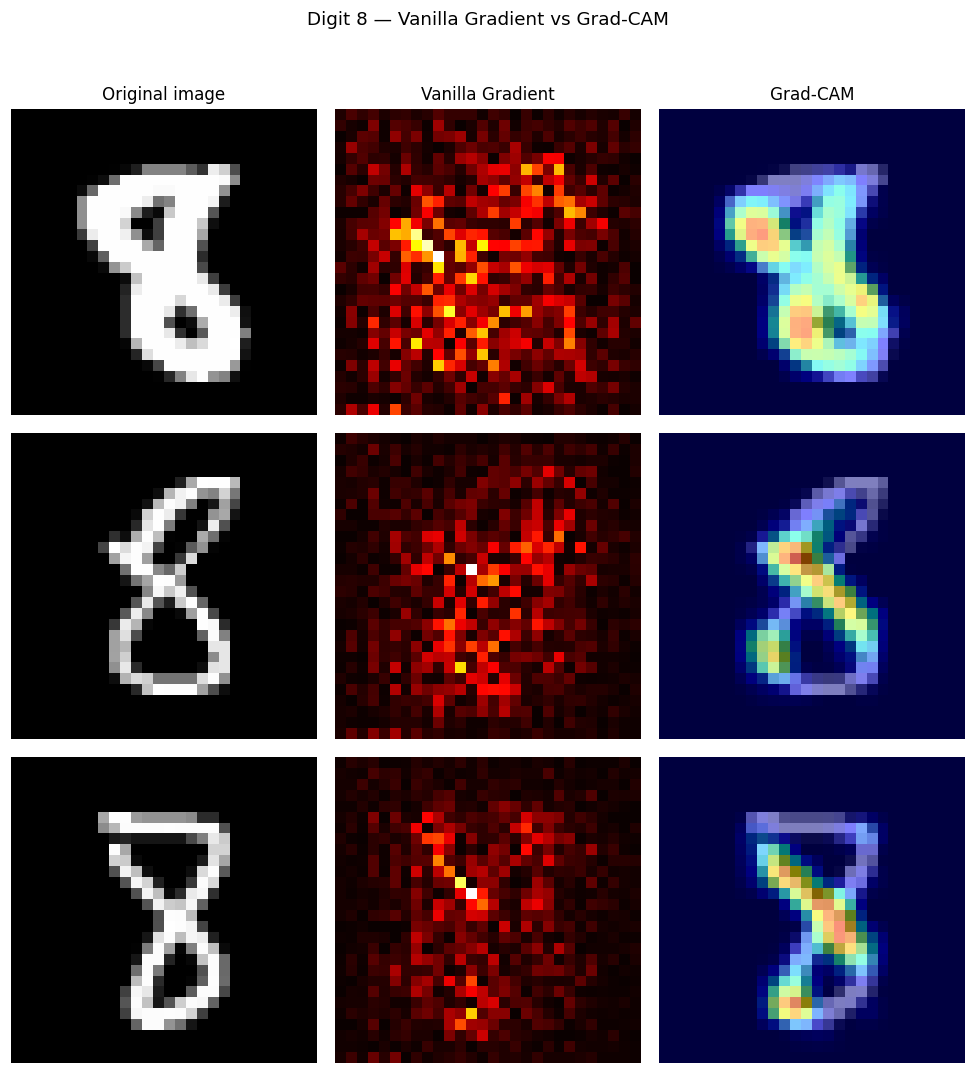

In [14]:
import matplotlib.cm as cm

def compare_methods(model, gcam_fn, dataset, digit_class, n_samples=3, save_path=None):
    """Show original | Vanilla Grad | Grad-CAM for n_samples of one digit class."""
    idxs = [i for i in range(len(dataset))
            if dataset[i][1] == digit_class
            and model(dataset[i][0].unsqueeze(0)).argmax(dim=1).item() == digit_class][:n_samples]

    if not idxs:
        print(f"No correctly classified samples for digit {digit_class}")
        return

    n   = len(idxs)
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Original image", "Vanilla Gradient", "Grad-CAM"]
    for j, title in enumerate(col_titles):
        axes[0][j].set_title(title, fontsize=11, pad=6)

    for row, ds_idx in enumerate(idxs):
        image, true_label = dataset[ds_idx]
        pred = model(image.unsqueeze(0)).argmax(dim=1).item()

        # Original
        img_np = image.squeeze().numpy() * STD + MEAN
        axes[row][0].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[row][0].set_ylabel(f"Sample {row+1}", fontsize=9)
        axes[row][0].axis("off")

        # Vanilla gradient
        sal = vanilla_gradient(model, image, pred)
        axes[row][1].imshow(sal, cmap="hot")
        axes[row][1].axis("off")

        # Grad-CAM
        heatmap = gcam_fn(image, pred)
        heatmap_rgb = cm.jet(heatmap)[:, :, :3]
        img_rgb     = np.stack([img_np] * 3, axis=-1)
        axes[row][2].imshow(np.clip(0.5 * heatmap_rgb + 0.5 * img_rgb, 0, 1))
        axes[row][2].axis("off")

    fig.suptitle(f"Digit {digit_class} — Vanilla Gradient vs Grad-CAM",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()


# Compare for digits 0, 3, 8 (visually interesting)
for d in [0, 3, 8]:
    compare_methods(model, gcam, test_ds, digit_class=d, n_samples=3,
                    save_path=f"compare_digit_{d}.png")


### Key observations

| | Vanilla Gradient | Grad-CAM |
|---|---|---|
| **Resolution** | High (28×28, pixel-level) | Low (7×7 upsampled) |
| **Noise** | Often noisy / scattered | Smoother, more regional |
| **What it highlights** | Individual sensitive pixels | Regions relevant to the class |
| **Where it comes from** | Input-space gradients | Last conv layer activations |
| **Best for** | Precise pixel attribution | Understanding which part of image matters |

**Summary:** Vanilla Gradient gives fine-grained but noisy attribution.
Grad-CAM gives a spatially coherent region-level explanation.
In practice, both are used together.


---
## 11. Examining Misclassifications

Saliency maps are especially revealing when the model is **wrong**.
They can show *why* the model confused one class for another.


In [15]:
# Find misclassified examples — at least 2 per pair of (true, predicted)
misclassified = [
    (i, test_labels[i], test_preds[i])
    for i in range(len(test_labels))
    if test_labels[i] != test_preds[i]
]
print(f"Total misclassified: {len(misclassified)}")
print("\nMost common confusions:")
from collections import Counter
conf_counter = Counter((t, p) for _, t, p in misclassified)
for (true, pred), count in conf_counter.most_common(5):
    print(f"  True={true} predicted as {pred} : {count} times")


Total misclassified: 18

Most common confusions:
  True=4 predicted as 9 : 2 times
  True=7 predicted as 2 : 2 times
  True=8 predicted as 7 : 2 times
  True=2 predicted as 7 : 1 times
  True=3 predicted as 8 : 1 times


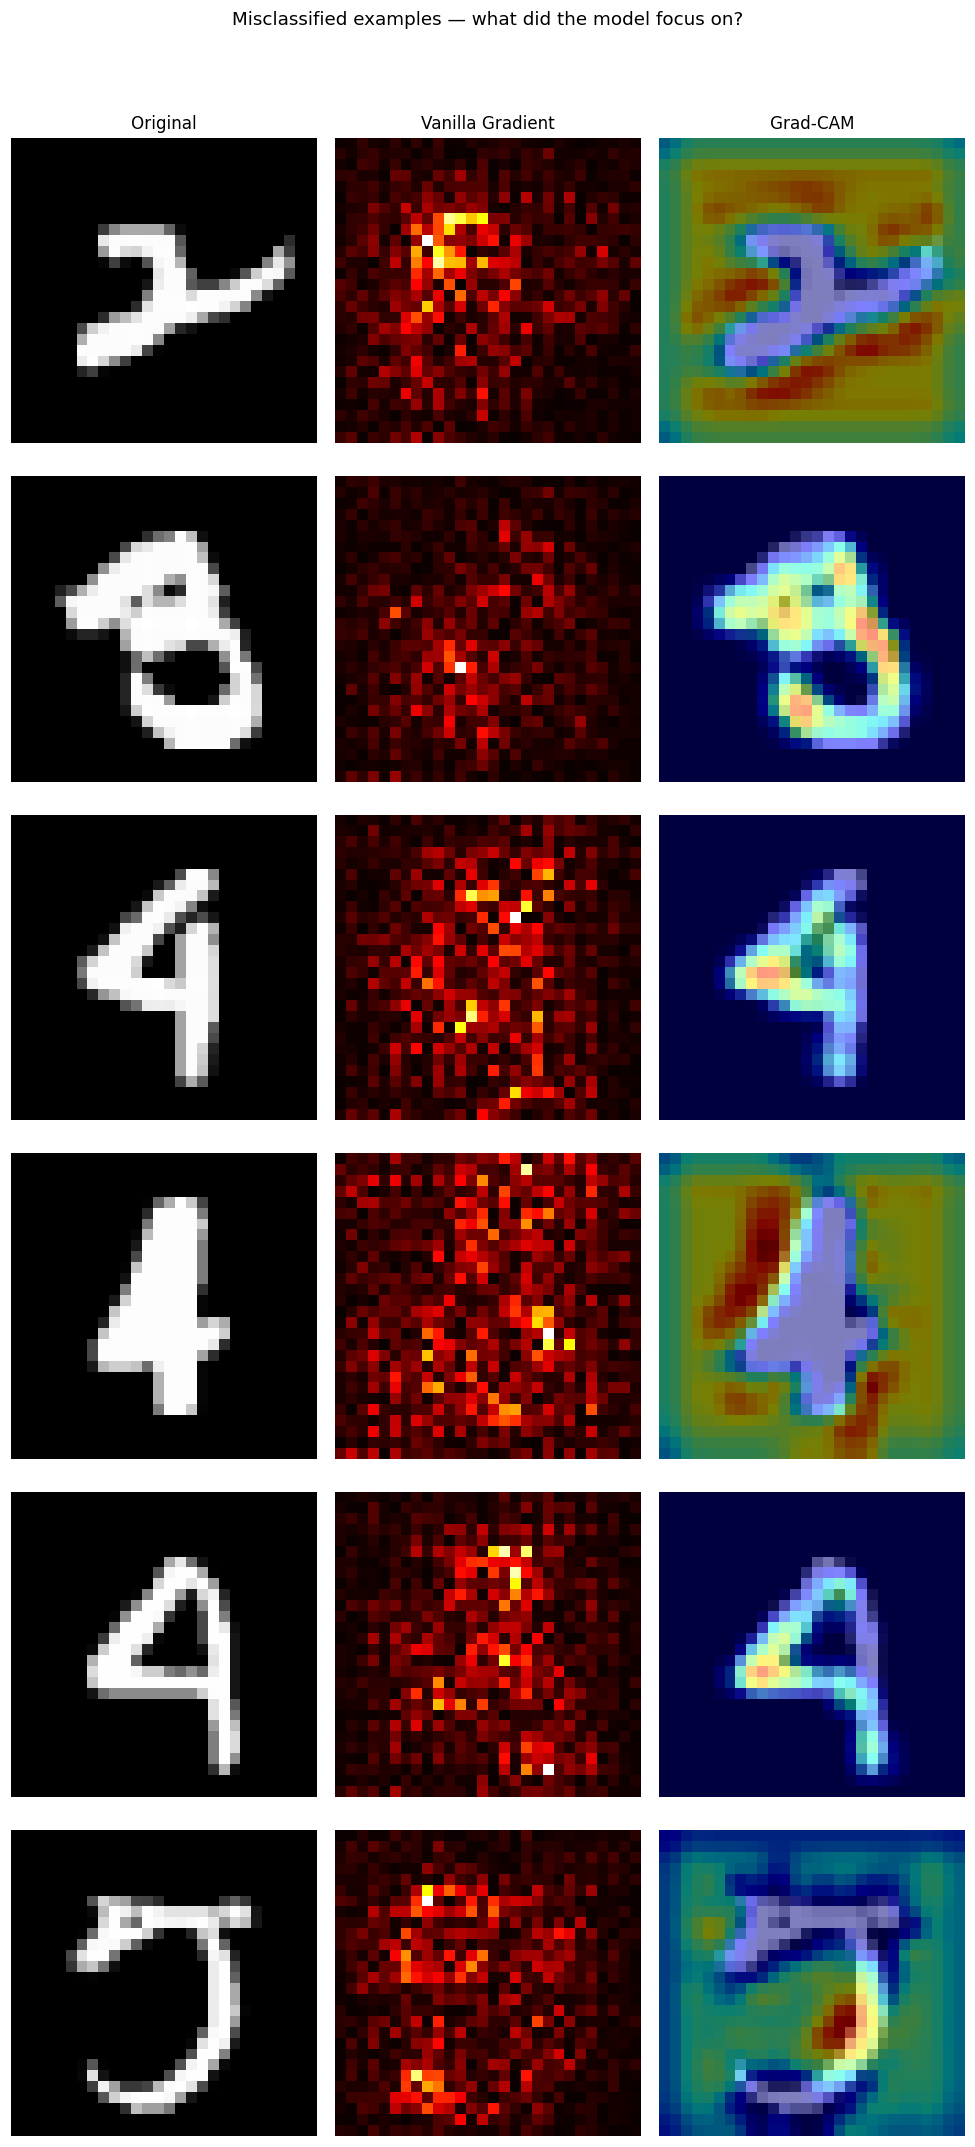

In [16]:
# Visualise saliency for misclassified examples
if misclassified:
    # Pick up to 6 misclassified examples
    mis_sample = misclassified[:6]
    n = len(mis_sample)
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]

    axes[0][0].set_title("Original", fontsize=11)
    axes[0][1].set_title("Vanilla Gradient", fontsize=11)
    axes[0][2].set_title("Grad-CAM", fontsize=11)

    for row, (ds_idx, true_lbl, pred_lbl) in enumerate(mis_sample):
        image, _ = test_ds[ds_idx]
        img_np   = image.squeeze().numpy() * STD + MEAN

        axes[row][0].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[row][0].set_ylabel(f"True:{true_lbl}\nPred:{pred_lbl}",
                                color="#EF4444", fontsize=9, rotation=0,
                                labelpad=40, va="center")
        axes[row][0].axis("off")

        sal = vanilla_gradient(model, image, pred_lbl)
        axes[row][1].imshow(sal, cmap="hot")
        axes[row][1].axis("off")

        heatmap = gcam(image, pred_lbl)
        heatmap_rgb = cm.jet(heatmap)[:, :, :3]
        axes[row][2].imshow(np.clip(0.5*heatmap_rgb + 0.5*np.stack([img_np]*3,-1),0,1))
        axes[row][2].axis("off")

    fig.suptitle("Misclassified examples — what did the model focus on?",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig("misclassified.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("No misclassifications found — model is perfect on this test set!")


---
## 12. Limitations

Saliency maps are widely used but have **serious failure modes**.
Understanding these is as important as knowing how to compute them.

---

### 12.1 Gradient saturation

**Problem:** In regions where the activation function (ReLU) is saturated (output = 0),
the gradient is exactly 0 regardless of the pixel value.
This makes vanilla gradient blind to those pixels, even if they are semantically important.

**Demonstration:**


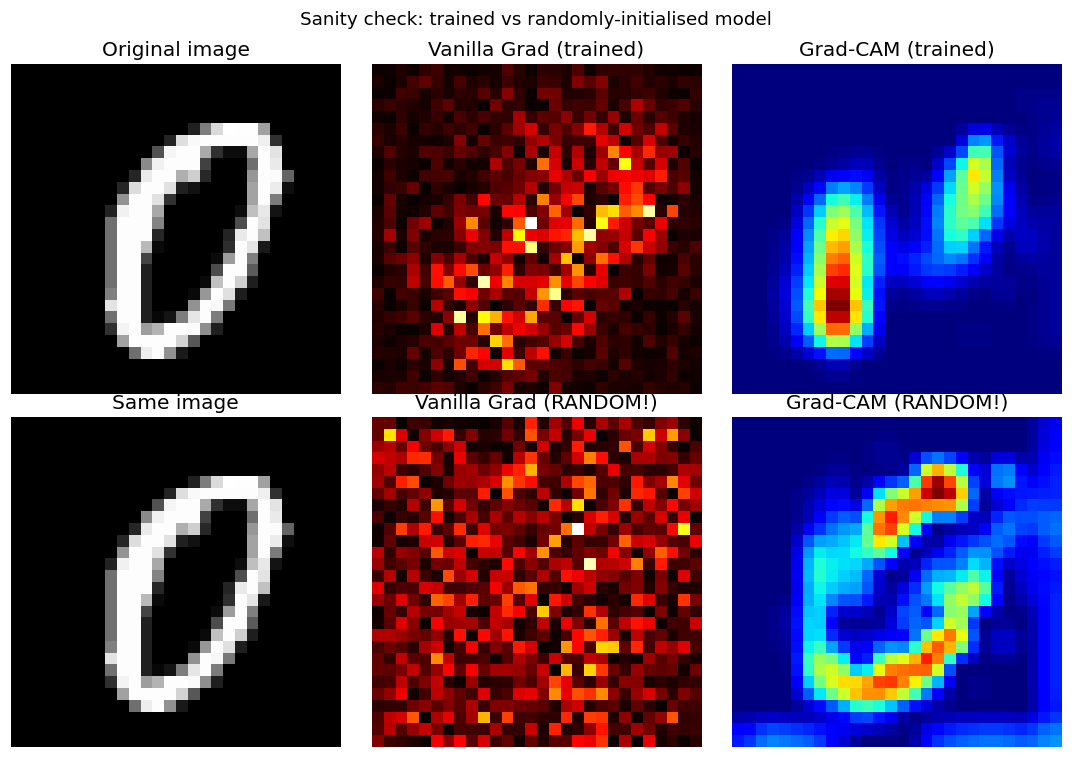


If saliency maps from a random model look similar to a trained model,
the method may not actually reflect what the model learned.
This is the 'sanity check failure' described by Adebayo et al. (2018).


In [17]:
# Show that saliency maps change dramatically with small model perturbations
# (sensitivity test from Adebayo et al., 2018)

torch.manual_seed(0)
# Create a randomly-initialised model (untrained)
random_model = DigitCNN().to(DEVICE)
gcam_random  = GradCAM(random_model, target_layer=random_model.conv2[0])

test_img, test_lbl = test_ds[0]
pred_trained = model(test_img.unsqueeze(0)).argmax(dim=1).item()

sal_trained  = vanilla_gradient(model, test_img, pred_trained)
sal_random   = vanilla_gradient(random_model, test_img, pred_trained)
cam_trained  = gcam(test_img, pred_trained)
cam_random   = gcam_random(test_img, pred_trained)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
img_np = test_img.squeeze().numpy() * STD + MEAN

for row_axes in axes:
    for ax in row_axes:
        ax.axis("off")

axes[0][0].imshow(img_np, cmap="gray"); axes[0][0].set_title("Original image")
axes[0][1].imshow(sal_trained,  cmap="hot"); axes[0][1].set_title("Vanilla Grad (trained)")
axes[0][2].imshow(cam_trained,  cmap="jet"); axes[0][2].set_title("Grad-CAM (trained)")

axes[1][0].imshow(img_np, cmap="gray"); axes[1][0].set_title("Same image")
axes[1][1].imshow(sal_random,   cmap="hot"); axes[1][1].set_title("Vanilla Grad (RANDOM!)")
axes[1][2].imshow(cam_random,   cmap="jet"); axes[1][2].set_title("Grad-CAM (RANDOM!)")

fig.suptitle("Sanity check: trained vs randomly-initialised model", fontsize=12)
plt.tight_layout()
plt.savefig("sanity_check.png", dpi=110, bbox_inches="tight")
plt.show()

gcam_random.remove_hooks()
print()
print("If saliency maps from a random model look similar to a trained model,")
print("the method may not actually reflect what the model learned.")
print("This is the 'sanity check failure' described by Adebayo et al. (2018).")


### 12.2 Saliency maps are not causal explanations

A high saliency value for pixel $(i,j)$ means: *"the model's score is sensitive to this pixel."*

It does **NOT** mean that the pixel *caused* the digit to be this class in the real world nor that removing this pixel would change the prediction or even that the model has "understood" the digit correctly.

### 12.3 Different methods give different answers

Vanilla Gradient, Grad-CAM, Integrated Gradients, and SHAP can all produce
**contradictory** rankings for the same image and model.
There is no ground truth to validate against.

### 12.4 High-confidence wrong predictions



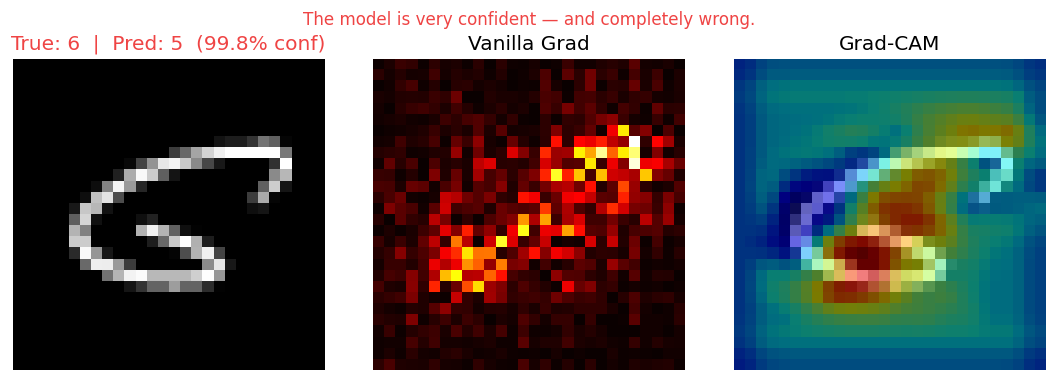

The saliency map looks 'reasonable' even though the prediction is wrong!
This shows saliency maps can give false confidence in a wrong prediction.


In [18]:
# Find a wrong prediction with high confidence
high_conf_wrong = []
for i in range(len(test_ds)):
    img, true_lbl = test_ds[i]
    with torch.no_grad():
        logits = model(img.unsqueeze(0))
        prob   = F.softmax(logits, dim=1)
    pred = logits.argmax(dim=1).item()
    conf = prob[0, pred].item()
    if pred != true_lbl and conf > 0.85:
        high_conf_wrong.append((i, true_lbl, pred, conf))

high_conf_wrong.sort(key=lambda x: -x[3])

if high_conf_wrong:
    ds_idx, true_lbl, pred_lbl, conf = high_conf_wrong[0]
    image, _ = test_ds[ds_idx]
    img_np   = image.squeeze().numpy() * STD + MEAN

    sal  = vanilla_gradient(model, image, pred_lbl)
    hmap = gcam(image, pred_lbl)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    axes[0].imshow(img_np, cmap="gray"); axes[0].axis("off")
    axes[0].set_title(f"True: {true_lbl}  |  Pred: {pred_lbl}  ({conf:.1%} conf)", color="#EF4444")
    axes[1].imshow(sal, cmap="hot"); axes[1].axis("off"); axes[1].set_title("Vanilla Grad")
    hmap_rgb = cm.jet(hmap)[:, :, :3]
    axes[2].imshow(np.clip(0.5*hmap_rgb + 0.5*np.stack([img_np]*3,-1),0,1))
    axes[2].axis("off"); axes[2].set_title("Grad-CAM")
    fig.suptitle("The model is very confident — and completely wrong.", fontsize=11, color="#EF4444")
    plt.tight_layout()
    plt.savefig("high_conf_wrong.png", dpi=110, bbox_inches="tight")
    plt.show()
    print(f"The saliency map looks 'reasonable' even though the prediction is wrong!")
    print("This shows saliency maps can give false confidence in a wrong prediction.")
else:
    print("No high-confidence errors found — model is very accurate!")


### 12.5 Summary of limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| **Gradient saturation** | Misses important pixels in ReLU-dead regions | Use Integrated Gradients or Guided Backprop |
| **Not causal** | High saliency != causal importance | Use causal attribution or perturbation-based methods |
| **Method disagreement** | Different methods, different answers | Always use multiple methods; look for consensus |
| **Sanity check failure** | Some methods give similar maps for random models | Run Adebayo et al. (2018) sanity checks |
| **Spatial resolution** | Grad-CAM is coarse (7×7 before upsampling) | Use Grad-CAM++ or Score-CAM for higher resolution |
| **Model-specific** | Works on classification; harder for regression or generation | Adapt gradient targets accordingly |


---
## 13. Exercises

---

### Exercise 1 — Explain the wrong class

For a correctly classified image of digit 3, compute Grad-CAM for:
- The **correct** class (3)
- The most likely **wrong** class (e.g., 8)

Do the heatmaps highlight different regions? What does that tell you?


In [19]:
# Exercise 1 scaffold
# Find a correctly classified 3
idxs_3 = [i for i in range(len(test_ds))
           if test_ds[i][1] == 3 and test_preds[i] == 3]

if idxs_3:
    img, _ = test_ds[idxs_3[0]]
    with torch.no_grad():
        logits = model(img.unsqueeze(0))
        probs  = F.softmax(logits, dim=1).squeeze()

    # Second most likely class
    top2 = probs.topk(2).indices.tolist()
    correct_class = top2[0]
    wrong_class   = top2[1]

    print(f"Correct class: {correct_class}  ({probs[correct_class]:.1%})")
    print(f"Second class : {wrong_class}  ({probs[wrong_class]:.1%})")

    # TODO: compute gcam(img, correct_class) and gcam(img, wrong_class)
    # TODO: plot side by side and describe what you see


Correct class: 3  (100.0%)
Second class : 9  (0.0%)


---

### Exercise 2 — SmoothGrad

**SmoothGrad** reduces noise in vanilla gradients by averaging over $N$ copies of the image,
each with small Gaussian noise added:

$$\text{SmoothGrad}(x) = \frac{1}{N} \sum_{n=1}^{N} \left| \frac{\partial S_c}{\partial (x + \epsilon_n)} \right|, \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2)$$

Implement SmoothGrad and compare its output to vanilla gradient. Try $\sigma \in \{0.05, 0.15, 0.30\}$.


In [20]:
# Exercise 2 scaffold
def smooth_grad(model, image, target_class, n_samples=50, sigma=0.15):
    """
    TODO: implement SmoothGrad.
    Hint: call vanilla_gradient(model, image + noise, target_class) n_samples times
          and average the results.
    """
    pass   # replace with your implementation

# Test your implementation:
# sal_smooth = smooth_grad(model, test_img, pred_class, n_samples=50, sigma=0.15)
# Compare to vanilla_gradient(model, test_img, pred_class) — which is smoother?


---

### Exercise 3 — Grad-CAM on the first conv layer

Instantiate a second `GradCAM` object that hooks into `model.conv1[0]` (the first conv layer)
instead of `model.conv2[0]`.

Compare the heatmaps from layer 1 vs layer 2:
- Which is coarser? Which highlights finer details?
- Does the first layer care about the same region as the last layer?


In [21]:
# Exercise 3 scaffold
gcam_layer1 = GradCAM(model, target_layer=model.conv1[0])

# TODO: for the same image, compute gcam_layer1(img, pred) and gcam(img, pred)
# TODO: plot side by side
# TODO: remember to call gcam_layer1.remove_hooks() when done


---

### Exercise 4 — Adversarial perturbation (conceptual + code)

An **adversarial example** is an image $x' = x + \delta$ where $\|\delta\|$ is tiny
(imperceptible to humans) but the model predicts a completely different class.

Using the gradient **ascent** direction on a *wrong* class, construct $\delta$ and show that:
1. The model's prediction changes.
2. The saliency map changes dramatically — even though the image looks identical.

This is the most striking demonstration of why saliency maps can be unreliable.


In [22]:
# Exercise 4 scaffold — Fast Gradient Sign Method (FGSM)
def fgsm_attack(model, image, true_class, epsilon=0.3):
    """
    Generate an adversarial example using FGSM.
    Returns the perturbed image (same shape as input).
    """
    x = image.unsqueeze(0).clone().to(DEVICE)
    x.requires_grad_(True)

    output = model(x)
    loss   = nn.CrossEntropyLoss()(output, torch.tensor([true_class]))
    model.zero_grad()
    loss.backward()

    # FGSM: move in the gradient sign direction
    perturbation = epsilon * x.grad.sign()
    x_adv = (x + perturbation).clamp(-3, 3)   # stay in normalised range
    return x_adv.squeeze().detach()


# TODO: pick an image, run fgsm_attack, check new prediction
# TODO: compare saliency maps of original vs adversarial image
# What do you observe?


---
## 14. Conclusion

### Steps

Starting from raw pixels, we:
1. Trained a CNN that classifies MNIST digits with >98% accuracy.
2. Implemented **Vanilla Gradient** from scratch — a pixel-sensitivity map derived from backpropagation.
3. Implemented **Grad-CAM** from scratch — a class activation map derived from the last conv layer's gradients and activations.
4. Visualised both methods on correct predictions, misclassifications, and adversarial examples.

### Summary

Saliency maps are a **diagnostic tool**, not a proof.
They can help you spot bugs (the model looking at the background instead of the object),
build intuition about what a network learned, and communicate results to stakeholders.

But they cannot replace rigorous evaluation, and they should never be used as the
sole justification for a high-stakes decision.

---

### Further reading

- Simonyan, K. et al. (2013). *Deep Inside Convolutional Networks*. arXiv:1312.6034 — original vanilla gradient paper.
- Selvaraju, R. et al. (2017). *Grad-CAM*. ICCV 2017 — the Grad-CAM paper.
- Adebayo, J. et al. (2018). *Sanity Checks for Saliency Maps*. NeurIPS 2018 — must-read critique.
- Molnar, C. (2022). *Interpretable Machine Learning* (free): https://christophm.github.io/interpretable-ml-book/
- Captum library (PyTorch): https://captum.ai — production-grade implementations of all methods.


In [23]:
# ── Clean up hooks ────────────────────────────
gcam.remove_hooks()
print("Hooks removed. All done!")
print()
print("Files created in this notebook:")
import os
nb_dir = os.path.dirname(os.path.abspath("__file__"))
for f in sorted(os.listdir(nb_dir)):
    if f.endswith((".png", ".pt", ".npz")):
        size = os.path.getsize(os.path.join(nb_dir, f))
        print(f"  {f:40s}  {size/1e3:6.1f} KB")


Hooks removed. All done!

Files created in this notebook:
  class_distribution.png                      45.1 KB
  cnn_mnist.pt                              3305.5 KB
  compare_digit_0.png                         35.5 KB
  compare_digit_3.png                         38.1 KB
  compare_digit_8.png                         34.4 KB
  confusion_matrix.png                        45.1 KB
  gradcam.png                                 59.7 KB
  high_conf_wrong.png                         25.7 KB
  mean_images.png                             53.1 KB
  misclassified.png                           58.7 KB
  mnist_subset.npz                          1838.1 KB
  sample_images.png                           75.8 KB
  sanity_check.png                            44.0 KB
  subset_balance.png                          29.1 KB
  training_curves.png                         44.0 KB
  vanilla_gradient.png                        85.3 KB
  vanilla_overlay.png                         46.6 KB
